In [21]:
from langgraph.graph import StateGraph, add_messages, START, END
from typing import TypedDict, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage

In [2]:
import requests
load_dotenv()

True

In [3]:
import os

In [4]:
model = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

In [57]:
search_tool = DuckDuckGoSearchRun()

@tool
def calculate(first_num: int, second_num: int, operation: str) -> int:
    '''
    This is a function that is used to calculate addition, subtraction, multiplication and division between two numbers
    '''
    try:
        if operation == 'add':
            return first_num + second_num
        elif operation == 'subtract':
            return first_num - second_num
        elif operation == 'multiplication':
            return first_num * second_num
        elif operation == 'division':
            return first_num // second_num
        else:
            return 'Invalid Operation'
    except Exception as e:
        return e

@tool
def get_stock_price(company: str):
    '''
    This is a function used to get live stock price of the company.
    '''

    API_KEY = os.getenv("ALPHA_VANTAGE_KEY")

    if not API_KEY:
        return "Error: ALPHA_VANTAGE_KEY not found in environment."

    URL = "https://www.alphavantage.co/query"

    params = {
        "function": "GLOBAL_QUOTE",
        "symbol": company,
        "apikey": API_KEY
    }

    response = requests.get(URL, params=params)

    return response.json()

In [58]:
tools = [search_tool, calculate, get_stock_price]
llm_wth_tools = model.bind_tools(tools)

In [59]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [60]:
def ChatNode(state: ChatState) -> ChatState:
    '''llm node that may call a tool or answer the query direclty'''
    message = state['messages']
    response = llm_wth_tools.invoke(message)
    return {'messages': [response]}

In [61]:
tool_node = ToolNode(tools)

In [62]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', ChatNode)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

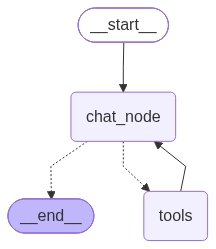

In [63]:
chatbot

In [54]:
out = chatbot.invoke({'messages': HumanMessage(content = 'hello!')})
print(out['messages'][-1].content)

Hello! How can I help you today?


In [55]:
out = chatbot.invoke({'messages': HumanMessage(content = 'what is 2*9?')})
print(out['messages'][-1].content)

2 * 9 = 18.


In [67]:
out = chatbot.invoke({'messages': HumanMessage(content = 'what is parent company of Youtube and what is its stock price')})
print(out['messages'][-1]['text'].content)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 35.48816028s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTi